<a href="https://colab.research.google.com/github/govt51717-design/01_ML_ALL_4_13_PRC/blob/main/ML_Microproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving bank-full.csv to bank-full (1).csv


In [91]:
import pandas as pd
import numpy as np
df = pd.read_csv("bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [92]:
print(df.shape)

(45211, 17)


In [93]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [95]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [96]:
df.duplicated().sum()

np.int64(0)

In [97]:
df.value_counts("y")

,count
y,
no,39922
yes,5289


In [98]:
df.replace("unknown", np.nan, inplace=True)
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2047/3324339567.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [99]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [100]:
X = df.drop("y", axis=1)
y = df["y"]

In [101]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [102]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [103]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

y
0    31937
1     4231
Name: count, dtype: int64
y
0    31937
1    31937
Name: count, dtype: int64


In [104]:
# X_train = X_train_smote
# y_train = y_train_smote

In [105]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8744885546831803


In [106]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8956098639831914


In [107]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8974897710936636


In [108]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8988167643481145


In [109]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

[[7808  177]
 [ 738  320]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.64      0.30      0.41      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043



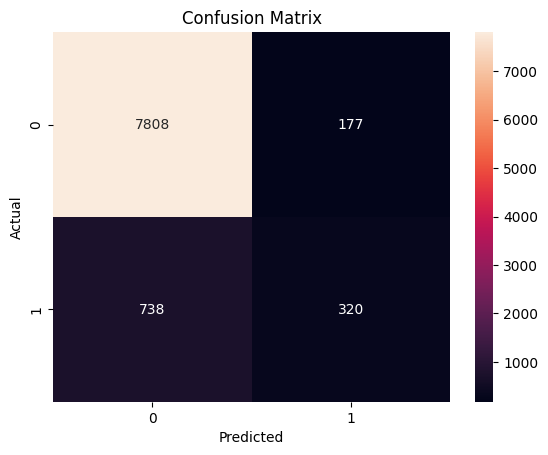

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [111]:
X_test_df = pd.DataFrame(X_test)

results = X_test_df.copy()

results["y_actual"] = y_test.values

results["DT_pred"] = y_pred_dt
results["KNN_pred"] = y_pred_knn
results["SVM_pred"] = y_pred_svm
results["LR_pred"] = y_pred_lr

results.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,y_actual,DT_pred,KNN_pred,SVM_pred,LR_pred
0,-0.088167,-1.011281,-0.275762,-1.751986,-0.13549,-0.237220,0.893915,2.289359,-0.262091,-0.938003,...,0.344964,-0.246560,-0.411453,-0.25194,-0.266514,0,0,0,0,0
1,0.288529,1.458223,-0.275762,-0.218740,-0.13549,-0.323270,0.893915,-0.436803,-0.262091,1.705471,...,-0.214205,-0.246560,-0.411453,-0.25194,-0.266514,0,0,0,0,0
2,-0.935732,0.840847,-0.275762,-0.218740,-0.13549,-0.330496,0.893915,-0.436803,-0.262091,0.503892,...,-0.117127,0.721811,-0.411453,-0.25194,-0.266514,0,0,0,0,0
3,-0.464863,-1.011281,-0.275762,-1.751986,-0.13549,-0.232294,0.893915,-0.436803,-0.262091,0.864365,...,-0.408361,0.399020,-0.411453,-0.25194,-0.266514,0,0,0,0,0
4,-0.653211,0.840847,1.368372,-0.218740,-0.13549,0.183506,0.893915,-0.436803,-0.262091,-1.418634,...,-0.765608,-0.569351,-0.411453,-0.25194,-0.266514,0,0,0,0,0


In [112]:
from sklearn.metrics import accuracy_score

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "KNN", "SVM", "Logistic"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_lr)
    ]
})

print(comparison)

           Model  Accuracy
0  Decision Tree  0.874489
1            KNN  0.895610
2            SVM  0.897490
3       Logistic  0.898817


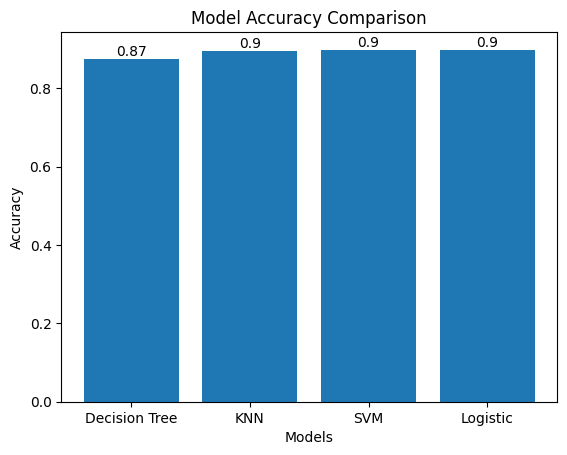

In [113]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(comparison["Model"], comparison["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(comparison["Accuracy"]):
    plt.text(i, v, round(v, 2), ha='center', va='bottom')

plt.show()

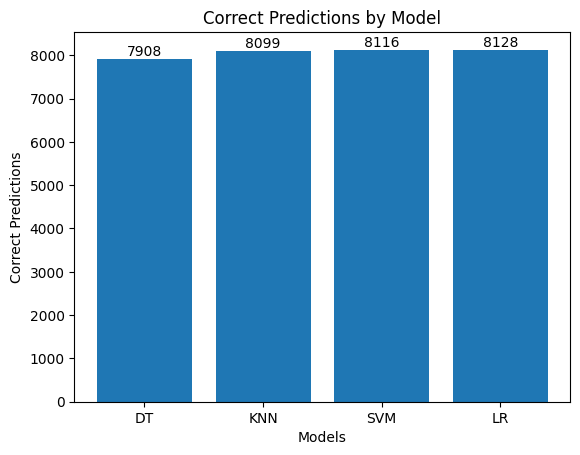

In [114]:
correct_dt = (y_test == y_pred_dt).sum()
correct_knn = (y_test == y_pred_knn).sum()
correct_svm = (y_test == y_pred_svm).sum()
correct_lr = (y_test == y_pred_lr).sum()

correct_counts = [correct_dt, correct_knn, correct_svm, correct_lr]
models = ["DT", "KNN", "SVM", "LR"]

plt.figure()
plt.bar(models, correct_counts)
plt.title("Correct Predictions by Model")
plt.xlabel("Models")
plt.ylabel("Correct Predictions")

for i, v in enumerate(correct_counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

Final Prediction DataFrame:
   age  job  marital  education  default  balance  housing  loan  contact  \
0   30    1        1          2        0     1000        1     0        0   
1   45    2        0          1        0     2000        1     1        1   
2   50    3        1          3        1     1500        0     0        0   

   day  month  duration  campaign  pdays  previous  poutcome  DT_pred  \
0    5      3       200         1    999         0         0        1   
1   10      5       300         2    999         1         1        1   
2   15      7       150         1      5         0         2        0   

   KNN_pred  SVM_pred  LR_pred  
0         1         1        0  
1         1         0        0  
2         0         0        1  


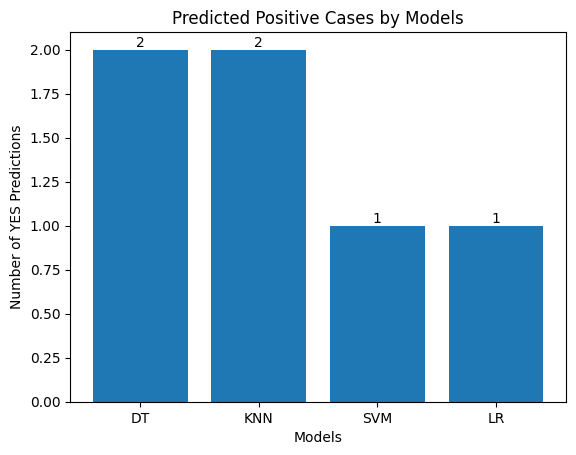

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

new_data = pd.DataFrame({
    'age': [30, 45, 50],
    'job': [1, 2, 3],
    'marital': [1, 0, 1],
    'education': [2, 1, 3],
    'default': [0, 0, 1],
    'balance': [1000, 2000, 1500],
    'housing': [1, 1, 0],
    'loan': [0, 1, 0],
    'contact': [0, 1, 0],
    'day': [5, 10, 15],
    'month': [3, 5, 7],
    'duration': [200, 300, 150],
    'campaign': [1, 2, 1],
    'pdays': [999, 999, 5],
    'previous': [0, 1, 0],
    'poutcome': [0, 1, 2]
})

new_data_scaled = scaler.transform(new_data)

pred_dt = dt.predict(new_data_scaled)
pred_knn = knn.predict(new_data_scaled)
pred_svm = svm.predict(new_data_scaled)
pred_lr = lr.predict(new_data_scaled)

final_df = new_data.copy()

final_df["DT_pred"] = pred_dt
final_df["KNN_pred"] = pred_knn
final_df["SVM_pred"] = pred_svm
final_df["LR_pred"] = pred_lr

print("Final Prediction DataFrame:")
print(final_df)

models = ["DT", "KNN", "SVM", "LR"]

yes_counts = [
    sum(pred_dt),
    sum(pred_knn),
    sum(pred_svm),
    sum(pred_lr)
]

plt.figure()

bars = plt.bar(models, yes_counts)

plt.title("Predicted Positive Cases by Models")
plt.xlabel("Models")
plt.ylabel("Number of YES Predictions")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, str(yval),
             ha='center', va='bottom')

plt.show()

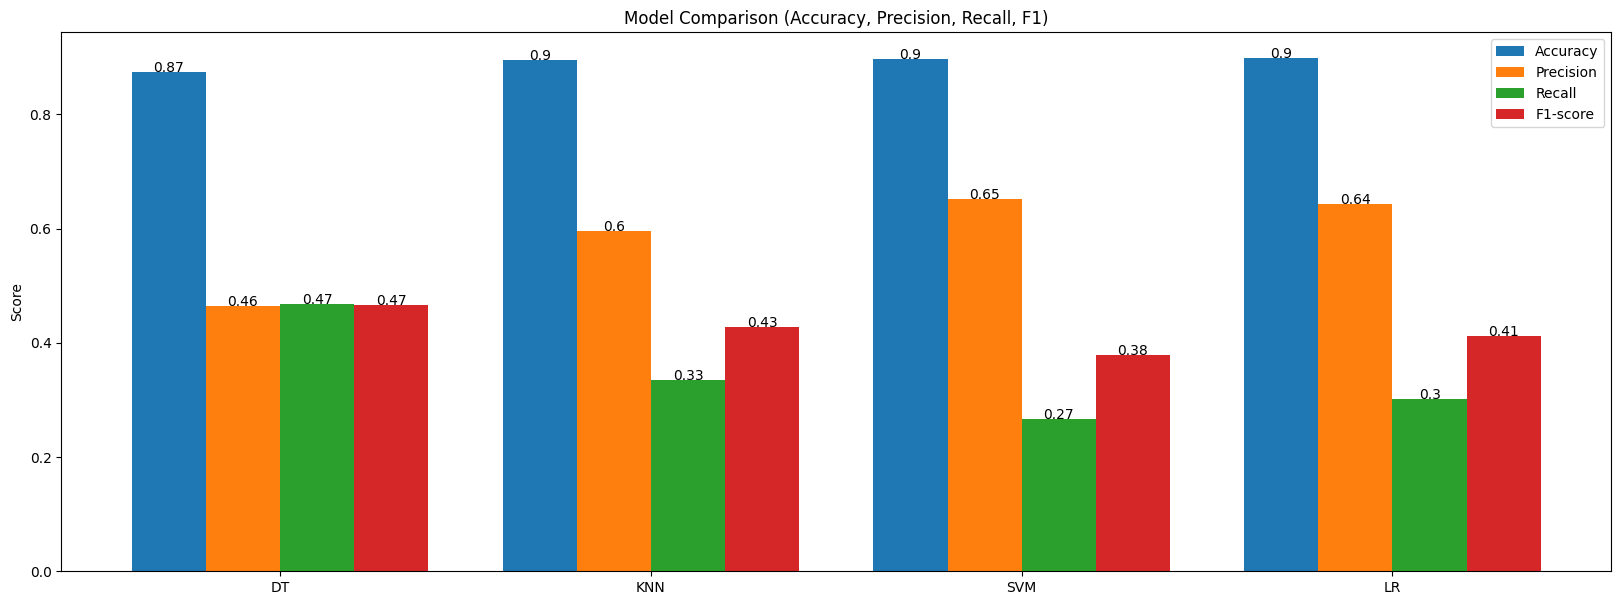

In [116]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

y_preds = [y_pred_dt, y_pred_knn, y_pred_svm, y_pred_lr]
model_names = ["DT", "KNN", "SVM", "LR"]

accuracy = [accuracy_score(y_test, y) for y in y_preds]
precision = [precision_score(y_test, y) for y in y_preds]
recall = [recall_score(y_test, y) for y in y_preds]
f1 = [f1_score(y_test, y) for y in y_preds]

x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(20,7))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1, width, label="F1-score")

plt.xticks(x, model_names)
plt.ylabel("Score")
plt.title("Model Comparison (Accuracy, Precision, Recall, F1)")

for i in range(len(model_names)):
    plt.text(x[i] - 1.5*width, accuracy[i], round(accuracy[i],2), ha='center')
    plt.text(x[i] - 0.5*width, precision[i], round(precision[i],2), ha='center')
    plt.text(x[i] + 0.5*width, recall[i], round(recall[i],2), ha='center')
    plt.text(x[i] + 1.5*width, f1[i], round(f1[i],2), ha='center')

plt.legend()
plt.show()